<a href="https://colab.research.google.com/github/KyryloKozlovskyi/garbage-classification/blob/main/garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waste Image Classification with CNNs

**Module:** Machine Learning Technologies  
**Student ID:** G00425385  
**Seed:** 425385  
**Dataset:** Garbage Classification — 10 categories, 384 × 384 RGB  

---
## 1. Environment Setup

All dependencies are imported upfront so the notebook can be restarted and re-run cleanly.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os, time, timeit, zipfile

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 425385
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow: {tf.__version__}')
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'GPU detected: {bool(gpu_devices)}  {gpu_devices}')

TensorFlow: 2.20.0
GPU detected: True  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Preparation

The dataset zip is stored on Google Drive. It is extracted to Colab's local disk for faster I/O during training.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---- Path configuration ----
ZIP_FILE = '/content/drive/MyDrive/garbage.zip'   # <- update if needed
LOCAL_DIR = '/content/garbage_dataset'

if not os.path.exists(ZIP_FILE):
    print(f'ERROR: {ZIP_FILE} not found.')
    print('Contents of Drive root:')
    for f in sorted(os.listdir('/content/drive/MyDrive'))[:15]:
        print(f'  {f}')
else:
    mb = os.path.getsize(ZIP_FILE) / 1024**2
    print(f'Zip found: {ZIP_FILE} ({mb:.0f} MB)')

Zip found: /content/drive/MyDrive/garbage.zip (390 MB)


In [4]:
# Extract once to local disk
if not os.path.exists(LOCAL_DIR):
    print('Extracting ...')
    with zipfile.ZipFile(ZIP_FILE, 'r') as zf:
        zf.extractall(LOCAL_DIR)
    print('Extraction complete.')
else:
    print('Already extracted.')

Extracting ...
Extraction complete.


In [5]:
# Locate the folder that holds the 10 class sub-directories
TARGET_CLASSES = {
    'battery', 'biological', 'cardboard', 'clothes', 'glass',
    'metal', 'paper', 'plastic', 'shoes', 'trash'
}

DATA_ROOT = None
for dirpath, dirnames, _ in os.walk(LOCAL_DIR):
    if TARGET_CLASSES.issubset(set(dirnames)):
        DATA_ROOT = dirpath
        break

if DATA_ROOT:
    print(f'Dataset root: {DATA_ROOT}')
else:
    print('Could not auto-detect — set DATA_ROOT manually below.')

Dataset root: /content/garbage_dataset/garbage


In [6]:
# Uncomment and set manually only if auto-detection failed
# DATA_ROOT = '/content/garbage_dataset/Garbage_data/Garbage_data'

---
## 3. Exploratory Data Analysis

### 3.1 Class Distribution

Before any modelling, inspecting how many images belong to each category reveals whether class imbalance is present. If one class dominates, accuracy becomes misleading because a model that always predicts the majority class can still score well.

In [7]:
# Count files in each class folder
categories = sorted(
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
)

img_counts = {}
for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    n = len([f for f in os.listdir(folder) if not f.startswith('.')])
    img_counts[cat] = n

total = sum(img_counts.values())
largest = max(img_counts, key=img_counts.get)
smallest = min(img_counts, key=img_counts.get)

print(f'{"Category":<14} {"Count":>6}')
print('-' * 22)
for cat, n in sorted(img_counts.items(), key=lambda x: -x[1]):
    print(f'{cat:<14} {n:>6}')
print('-' * 22)
print(f'{"Total":<14} {total:>6}')
print()
print(f'Largest:  {largest} ({img_counts[largest]})')
print(f'Smallest: {smallest} ({img_counts[smallest]})')
print(f'Ratio:    {img_counts[largest] / img_counts[smallest]:.1f}x')

Category        Count
----------------------
clothes          1892
glass            1736
plastic          1597
shoes            1449
cardboard        1411
paper            1336
metal             930
battery           756
biological        699
trash             453
----------------------
Total           12259

Largest:  clothes (1892)
Smallest: trash (453)
Ratio:    4.2x


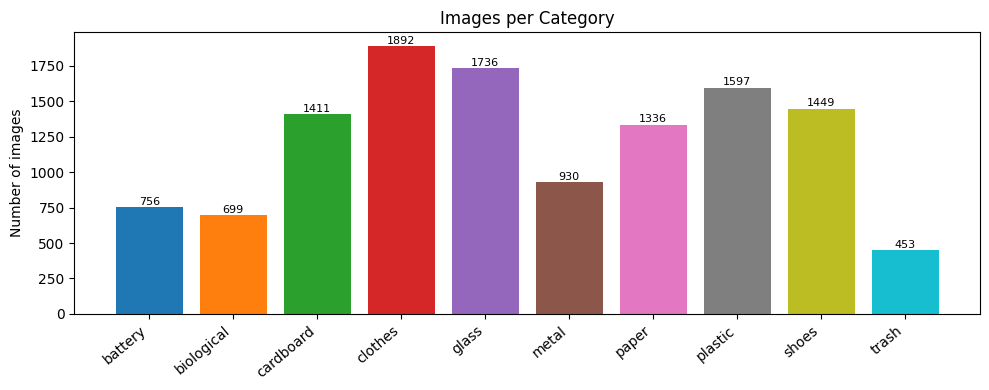

In [8]:
# Visualise the distribution
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(img_counts.keys(), img_counts.values(),
              color=plt.cm.tab10.colors[:len(img_counts)])

for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 15,
            int(b.get_height()), ha='center', fontsize=8)

ax.set_ylabel('Number of images')
ax.set_title('Images per Category')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Sample Images

Viewing a few images from every class gives an intuition for how varied the data is and which categories might be visually similar.

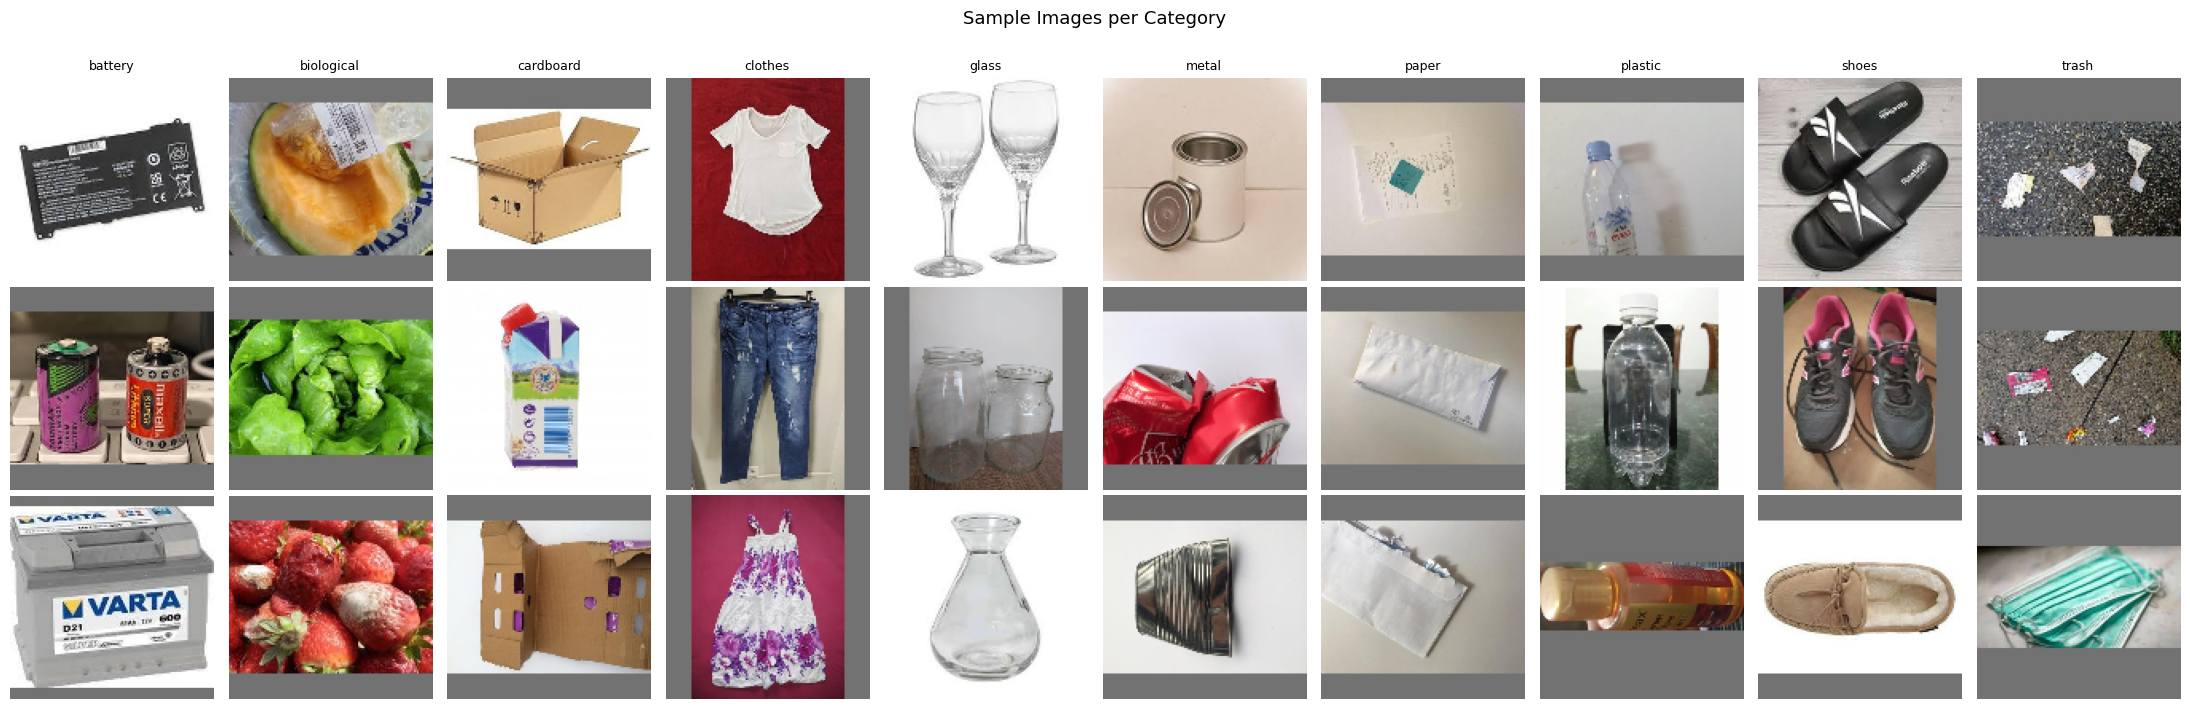

In [9]:
n_show = 3  # images per class
fig, axes = plt.subplots(n_show, len(categories), figsize=(22, 7))

for col_idx, cat in enumerate(categories):
    folder = os.path.join(DATA_ROOT, cat)
    samples = sorted(os.listdir(folder))[:n_show]
    for row_idx, fname in enumerate(samples):
        img = tf.keras.utils.load_img(
            os.path.join(folder, fname), target_size=(128, 128)
        )
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
    axes[0, col_idx].set_title(cat, fontsize=9)

fig.suptitle('Sample Images per Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Image Dimensions and Pixel Values

Confirming that images have consistent dimensions and checking the raw pixel range.

In [10]:
# Sample a few images per class to check dimensions
shapes_seen = set()
px_lo, px_hi = 255, 0

for cat in categories:
    folder = os.path.join(DATA_ROOT, cat)
    for fname in sorted(os.listdir(folder))[:5]:
        arr = np.array(
            tf.keras.utils.load_img(os.path.join(folder, fname))
        )
        shapes_seen.add(arr.shape)
        px_lo = min(px_lo, arr.min())
        px_hi = max(px_hi, arr.max())

print(f'Unique shapes found: {shapes_seen}')
print(f'Pixel range: [{px_lo}, {px_hi}]')

Unique shapes found: {(384, 384, 3)}
Pixel range: [0, 255]


---
## 4. Data Loading and Splitting

The data is loaded with `image_dataset_from_directory` and split 70 / 10 / 20 (train / validation / test). Keras only supports a single split parameter, so a 70/30 split is performed first, then the 30 % holdout is divided into one-third validation and two-thirds test.

The **validation** set is used throughout to compare models and select hyperparameters. The **test** set is reserved for a single final evaluation of the chosen model.

In [11]:
# ---- Hyperparameters ----
IMG_H = 128
IMG_W = 128
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

In [12]:
# 70 % training
ds_train = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# 30 % holdout
ds_holdout = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=(IMG_H, IMG_W),
    batch_size=BATCH,
    label_mode='int'
)

# Split holdout: first third → validation, remainder → test
holdout_size = tf.data.experimental.cardinality(ds_holdout).numpy()
n_val = holdout_size // 3

ds_val = ds_holdout.take(n_val)
ds_test = ds_holdout.skip(n_val)

label_names = ds_train.class_names
n_classes = len(label_names)

print(f'Labels ({n_classes}): {label_names}')
print(f'Batches  — train: {tf.data.experimental.cardinality(ds_train).numpy()}, '
      f'val: {tf.data.experimental.cardinality(ds_val).numpy()}, '
      f'test: {tf.data.experimental.cardinality(ds_test).numpy()}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Labels (10): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Batches  — train: 269, val: 38, test: 77


In [13]:
# Verify split sizes
n_train = sum(labels.shape[0] for _, labels in ds_train)
n_val_img = sum(labels.shape[0] for _, labels in ds_val)
n_test = sum(labels.shape[0] for _, labels in ds_test)

print(f'Images   — train: {n_train}, val: {n_val_img}, test: {n_test}')
print(f'Total: {n_train + n_val_img + n_test}')

Images   — train: 8582, val: 1216, test: 2461
Total: 12259


In [14]:
# Quick sanity check: shape and range of one batch
for batch_imgs, batch_labels in ds_train.take(1):
    print(f'Image batch: {batch_imgs.shape}  dtype={batch_imgs.dtype}')
    print(f'Label batch: {batch_labels.shape}  dtype={batch_labels.dtype}')
    print(f'Pixel range: [{batch_imgs.numpy().min():.0f}, {batch_imgs.numpy().max():.0f}]')

Image batch: (32, 128, 128, 3)  dtype=<dtype: 'float32'>
Label batch: (32,)  dtype=<dtype: 'int32'>
Pixel range: [0, 255]


### 4.1 Class Weights

Because the dataset is imbalanced, class weights are computed so that misclassifying a rare category (e.g. trash) costs more than misclassifying a common one (e.g. clothes). These weights are passed to `model.fit()` through the `class_weight` parameter.

In [15]:
# Gather all training labels
all_train_labels = np.concatenate(
    [labels.numpy() for _, labels in ds_train]
)

cw = compute_class_weight(
    'balanced',
    classes=np.arange(n_classes),
    y=all_train_labels
)
class_weights = {i: w for i, w in enumerate(cw)}

print(f'{"Class":<14} {"Weight":>8}')
print('-' * 24)
for i, name in enumerate(label_names):
    print(f'{name:<14} {class_weights[i]:>8.4f}')

Class            Weight
------------------------
battery          1.5718
biological       1.7130
cardboard        0.8642
clothes          0.6571
glass            0.6910
metal            1.3451
paper            0.9525
plastic          0.7711
shoes            0.8284
trash            2.8046


### 4.2 Performance Optimisation

Prefetching allows the data pipeline to prepare the next batch while the GPU is training on the current one.

In [16]:
ds_train = ds_train.cache().prefetch(AUTOTUNE)
ds_val   = ds_val.cache().prefetch(AUTOTUNE)
ds_test  = ds_test.cache().prefetch(AUTOTUNE)

---
## 5. Utility Functions

Reusable helpers for plotting training curves, computing metrics, and displaying confusion matrices.

In [17]:
def show_curves(hist, title=''):
    """Side-by-side accuracy and loss plots from a Keras History object."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    a1.plot(hist.history['accuracy'],     label='train')
    a1.plot(hist.history['val_accuracy'],  label='val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.legend(); a1.grid(True, alpha=0.3)

    a2.plot(hist.history['loss'],     label='train')
    a2.plot(hist.history['val_loss'],  label='val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def get_predictions(model, dataset):
    """Return ground-truth and predicted label arrays for a dataset."""
    y_true, y_pred = [], []
    for imgs, lbls in dataset:
        logits = model.predict(imgs, verbose=0)
        y_true.append(lbls.numpy())
        y_pred.append(np.argmax(logits, axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)


def report_metrics(model, dataset, tag='Validation'):
    """Print accuracy, macro-F1, per-class report, and return predictions."""
    y_true, y_pred = get_predictions(model, dataset)

    acc  = np.mean(y_true == y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')

    print(f'\n=== {tag} ===')
    print(f'Accuracy :  {acc:.4f}')
    print(f'Macro F1 :  {mf1:.4f}')
    print(f'Parameters: {model.count_params():,}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=label_names))
    return y_true, y_pred, mf1


def show_confusion(y_true, y_pred, title=''):
    """Display a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap='Oranges', xticks_rotation=45)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


def measure_inference(model, dataset, n_runs=10):
    """Average inference time over n_runs using timeit on one batch."""
    one_batch = next(iter(dataset))[0]
    t = timeit.timeit(
        lambda: model.predict(one_batch, verbose=0),
        number=n_runs
    ) / n_runs
    print(f'Mean inference time (1 batch, {n_runs} runs): {t:.4f} s')
    return t

---
## 6. Data Augmentation

Data augmentation creates slightly different versions of each training image on every epoch (flipping, rotating, etc.). This helps the model learn general features rather than memorising specific training images, which reduces overfitting.

The augmentation layer is placed inside the model so it only runs during training and is automatically disabled at inference time.

In [18]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

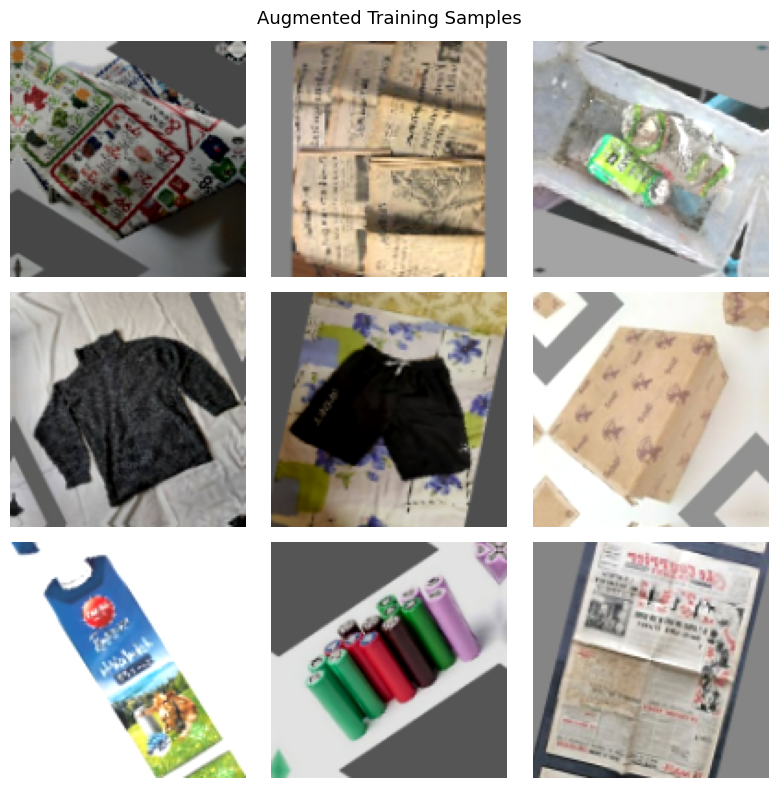

In [19]:
# Preview augmented images
sample_batch = next(iter(ds_train))[0][:9]  # grab 9 images

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    augmented = augmentation(tf.expand_dims(sample_batch[i], 0))
    ax.imshow(augmented[0].numpy().astype('uint8'))
    ax.axis('off')
fig.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. CNN from Scratch (RGB, 128x128)

### 7.1 Baseline Model

The first model follows the same pattern used in the beans classification lab: three convolutional blocks with increasing filter counts (16, 32, 64), each followed by max pooling. A `Rescaling` layer normalises pixel values from [0, 255] to [0, 1].

The output layer has no activation function; instead, `from_logits=True` is set in the loss function, which is numerically more stable than applying softmax separately.

In [20]:
# Baseline RGB CNN
rgb_baseline = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes)  # no activation, using from_logits=True
])

rgb_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the baseline
EPOCHS = 30

t0 = time.time()
hist_baseline = rgb_baseline.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    class_weight=class_weights,
)
baseline_time = time.time() - t0
print(f'\nTraining time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)')

Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.1371 - loss: 2.1822 - val_accuracy: 0.1817 - val_loss: 2.1152
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2490 - loss: 2.0240 - val_accuracy: 0.2426 - val_loss: 2.1074
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3129 - loss: 1.8816 - val_accuracy: 0.3273 - val_loss: 1.9293
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3450 - loss: 1.8069 - val_accuracy: 0.3363 - val_loss: 1.8816
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3649 - loss: 1.7587 - val_accuracy: 0.3438 - val_loss: 1.9100
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3804 - loss: 1.7201 - val_accuracy: 0.3643 - val_loss: 1.8433
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3976 - loss: 1.6832 - val_accuracy: 0.3791 - val_loss: 1.7802
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4045 - loss: 1.6500 - val_acc

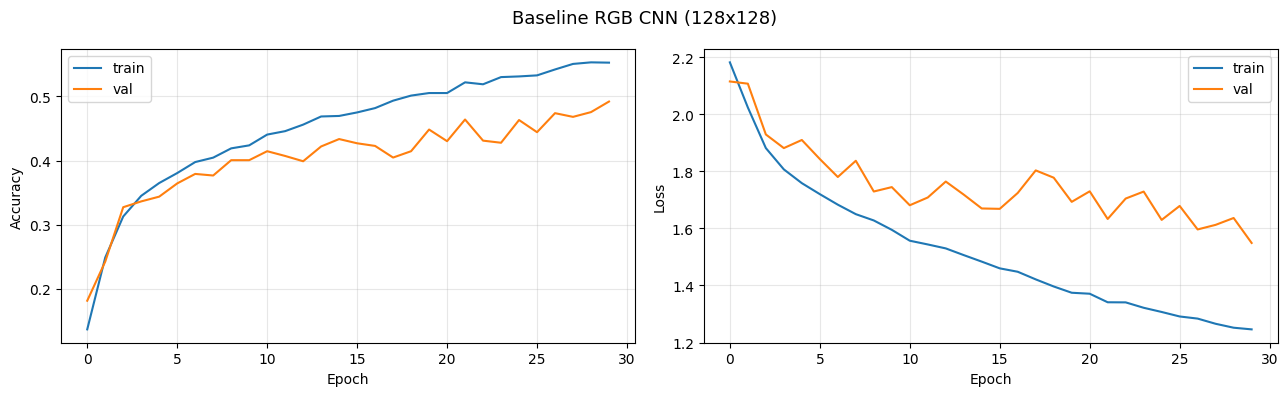

In [22]:
show_curves(hist_baseline, 'Baseline RGB CNN (128x128)')

In [23]:
y_true_b, y_pred_b, f1_baseline = report_metrics(
    rgb_baseline, ds_val, tag='Baseline RGB (128) - Validation'
)


=== Baseline RGB (128) - Validation ===
Accuracy :  0.4918
Macro F1 :  0.4710
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.50      0.78      0.61        68
  biological       0.51      0.60      0.55        78
   cardboard       0.53      0.75      0.62       139
     clothes       0.70      0.62      0.66       198
       glass       0.71      0.21      0.33       163
       metal       0.32      0.44      0.37        95
       paper       0.38      0.65      0.48       135
     plastic       0.67      0.31      0.42       169
       shoes       0.41      0.29      0.34       126
       trash       0.28      0.42      0.33        45

    accuracy                           0.49      1216
   macro avg       0.50      0.51      0.47      1216
weighted avg       0.54      0.49      0.48      1216



### 7.2 Diagnosis and Iteration

Looking at the training curves above, the gap between training and validation tells us whether the model is overfitting or underfitting.

If the training accuracy keeps climbing while validation accuracy levels off, that means the model is memorising the training data. To address this, the next model adds dropout after each pooling layer and uses early stopping to halt training when validation loss stops improving.

In [24]:
# Improved RGB CNN with dropout and early stopping
rgb_v2 = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 3
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rgb_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,194 (129.66 KB)

 Trainable params: 33,194 (129.66 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

t0 = time.time()
hist_v2 = rgb_v2.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop],
)
v2_time = time.time() - t0
print(f'\nTraining time: {v2_time:.1f}s ({v2_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1100 - loss: 2.2403 - val_accuracy: 0.1924 - val_loss: 2.1741
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1862 - loss: 2.1322 - val_accuracy: 0.2426 - val_loss: 2.0824
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2309 - loss: 2.0598 - val_accuracy: 0.2722 - val_loss: 2.0514
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2672 - loss: 1.9998 - val_accuracy: 0.2780 - val_loss: 2.0819
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2905 - loss: 1.9463 - val_accuracy: 0.2812 - val_loss: 2.0724
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3113 - loss: 1.9127 - val_accuracy: 0.2763 - val_loss: 2.0618
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3148 - loss: 1.8891 - val_accuracy: 0.3092 - val_loss: 1.9759
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3244 - loss: 1.8645 - val_accu

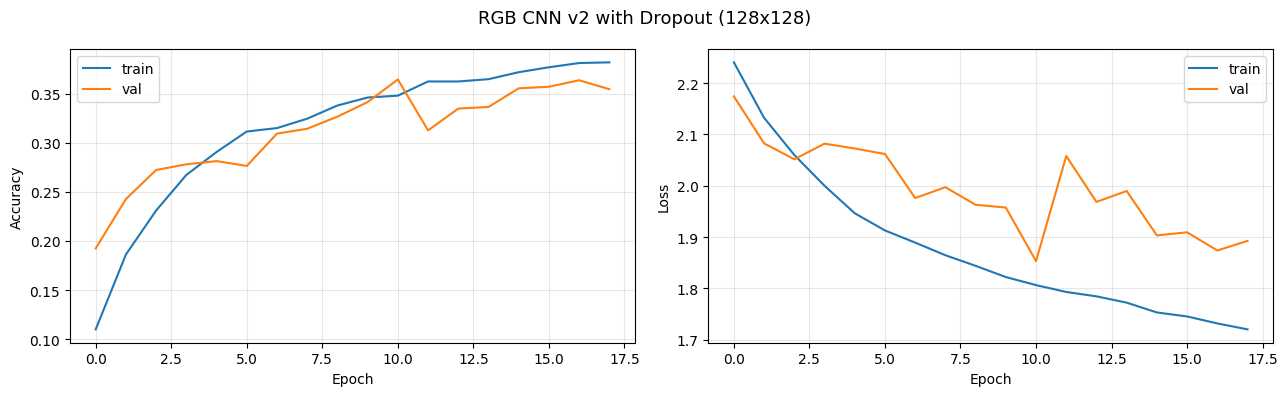

In [26]:
show_curves(hist_v2, 'RGB CNN v2 with Dropout (128x128)')

In [27]:
y_true_v2, y_pred_v2, f1_v2 = report_metrics(
    rgb_v2, ds_val, tag='RGB v2 with Dropout (128) - Validation'
)


=== RGB v2 with Dropout (128) - Validation ===
Accuracy :  0.3643
Macro F1 :  0.3235
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.32      0.78      0.45        68
  biological       0.36      0.72      0.48        78
   cardboard       0.36      0.50      0.42       139
     clothes       0.51      0.49      0.50       198
       glass       0.52      0.10      0.17       163
       metal       0.12      0.07      0.09        95
       paper       0.31      0.55      0.40       135
     plastic       0.48      0.31      0.37       169
       shoes       0.15      0.06      0.08       126
       trash       0.38      0.20      0.26        45

    accuracy                           0.36      1216
   macro avg       0.35      0.38      0.32      1216
weighted avg       0.37      0.36      0.33      1216



### 7.3 Deeper Network

The project spec asks whether adding more convolutional layers helps. This version adds a fourth block with 128 filters to see if extra depth can pick up finer details in the images.

In [28]:
# Deeper CNN with 4 convolutional blocks
rgb_deep = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 3)),
    augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Parameters: {rgb_deep.count_params():,}')

Parameters: 115,242


In [29]:
t0 = time.time()
hist_deep = rgb_deep.fit(
    ds_train,
    validation_data=ds_val,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
deep_time = time.time() - t0
print(f'\nTraining time: {deep_time:.1f}s ({deep_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.1190 - loss: 2.2378 - val_accuracy: 0.1406 - val_loss: 2.2028
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.1855 - loss: 2.1266 - val_accuracy: 0.2541 - val_loss: 2.0897
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2745 - loss: 1.9993 - val_accuracy: 0.3059 - val_loss: 2.0306
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.3145 - loss: 1.9272 - val_accuracy: 0.3306 - val_loss: 1.9917
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.3335 - loss: 1.8670 - val_accuracy: 0.3405 - val_loss: 1.8872
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3484 - loss: 1.8249 - val_accuracy: 0.3610 - val_loss: 1.8236
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3696 - loss: 1.7855 - val_accuracy: 0.3701 - val_loss: 1.7932
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3802 - loss: 1.7519 - val_acc

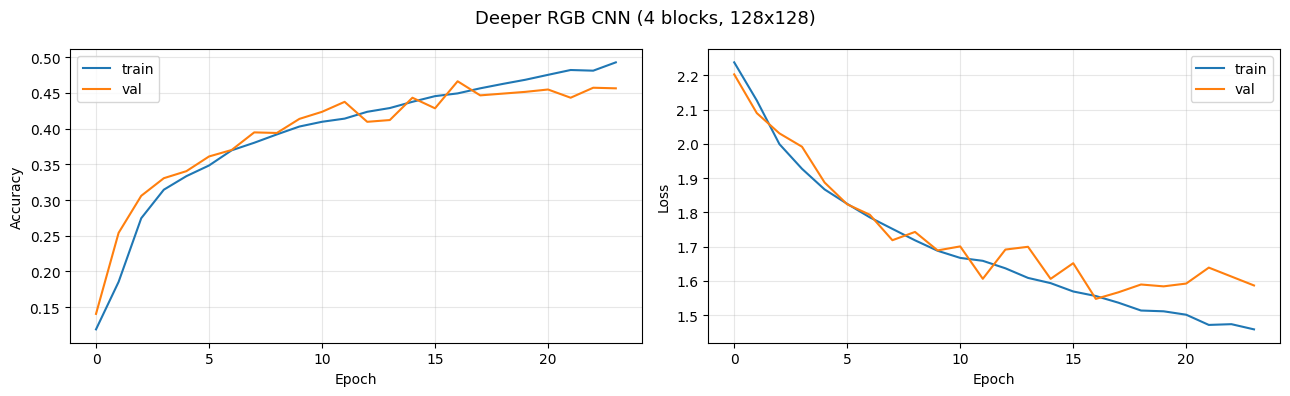

In [30]:
show_curves(hist_deep, 'Deeper RGB CNN (4 blocks, 128x128)')

In [31]:
y_true_d, y_pred_d, f1_deep = report_metrics(
    rgb_deep, ds_val, tag='Deeper RGB CNN (128) - Validation'
)


=== Deeper RGB CNN (128) - Validation ===
Accuracy :  0.4663
Macro F1 :  0.4338
Parameters: 115,242

              precision    recall  f1-score   support

     battery       0.44      0.79      0.57        68
  biological       0.51      0.77      0.62        78
   cardboard       0.53      0.71      0.61       139
     clothes       0.59      0.59      0.59       198
       glass       0.68      0.23      0.35       163
       metal       0.24      0.17      0.20        95
       paper       0.36      0.64      0.46       135
     plastic       0.56      0.36      0.43       169
       shoes       0.39      0.17      0.23       126
       trash       0.24      0.36      0.29        45

    accuracy                           0.47      1216
   macro avg       0.45      0.48      0.43      1216
weighted avg       0.49      0.47      0.44      1216



### 7.4 Smaller Image Size (64x64)

The spec asks to compare at least two image sizes. Training on 64x64 images is much faster and uses less memory. The trade-off is that shrinking the image throws away fine detail, which could hurt accuracy for categories that rely on texture differences (like paper vs cardboard).

In [32]:
# Load data at 64x64
IMG_SMALL = 64

ds_train_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)
ds_holdout_64 = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_SMALL, IMG_SMALL),
    batch_size=BATCH, label_mode='int'
)

h64 = tf.data.experimental.cardinality(ds_holdout_64).numpy()
ds_val_64  = ds_holdout_64.take(h64 // 3).cache().prefetch(AUTOTUNE)
ds_test_64 = ds_holdout_64.skip(h64 // 3).cache().prefetch(AUTOTUNE)
ds_train_64 = ds_train_64.cache().prefetch(AUTOTUNE)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [33]:
# Same architecture as v2 but input is 64x64
augmentation_64 = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
])

rgb_small = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SMALL, IMG_SMALL, 3)),
    augmentation_64,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

rgb_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Parameters: {rgb_small.count_params():,}')

Parameters: 33,194


In [34]:
t0 = time.time()
hist_small = rgb_small.fit(
    ds_train_64,
    validation_data=ds_val_64,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
small_time = time.time() - t0
print(f'\nTraining time: {small_time:.1f}s ({small_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.1191 - loss: 2.2322 - val_accuracy: 0.1628 - val_loss: 2.1953
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.1514 - loss: 2.1500 - val_accuracy: 0.1801 - val_loss: 2.1378
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.1850 - loss: 2.0757 - val_accuracy: 0.2632 - val_loss: 2.0496
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2622 - loss: 1.9632 - val_accuracy: 0.3141 - val_loss: 2.0140
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2960 - loss: 1.9146 - val_accuracy: 0.3199 - val_loss: 1.9840
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3095 - loss: 1.8924 - val_accuracy: 0.3174 - val_loss: 2.0119
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3133 - loss: 1.8729 - val_accuracy: 0.3109 - val_loss: 2.0034
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3246 - loss: 1.8501 - val_accurac

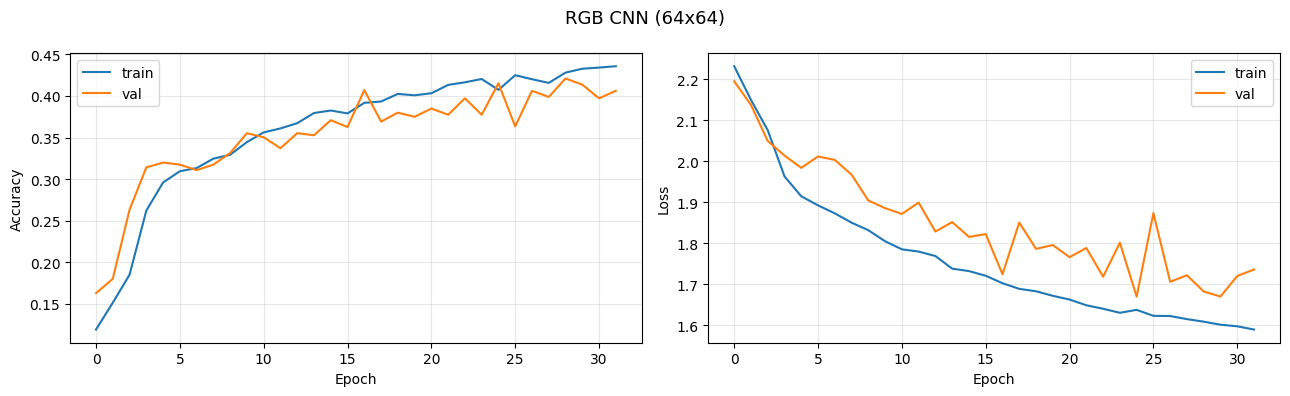

In [35]:
show_curves(hist_small, 'RGB CNN (64x64)')

In [36]:
y_true_s, y_pred_s, f1_small = report_metrics(
    rgb_small, ds_val_64, tag='RGB CNN (64x64) - Validation'
)


=== RGB CNN (64x64) - Validation ===
Accuracy :  0.4153
Macro F1 :  0.3714
Parameters: 33,194

              precision    recall  f1-score   support

     battery       0.33      0.85      0.48        67
  biological       0.35      0.84      0.49        76
   cardboard       0.47      0.50      0.48       139
     clothes       0.66      0.59      0.62       204
       glass       0.56      0.25      0.34       170
       metal       0.20      0.11      0.15        87
       paper       0.31      0.52      0.39       130
     plastic       0.64      0.25      0.36       171
       shoes       0.30      0.21      0.25       129
       trash       0.17      0.14      0.15        43

    accuracy                           0.42      1216
   macro avg       0.40      0.43      0.37      1216
weighted avg       0.46      0.42      0.40      1216



### 7.5 RGB Model Comparison

Comparing all RGB scratch models side by side on the validation set. The primary metric is macro F1, as it accounts for class imbalance.

In [37]:
# Summary table
scratch_results = {
    'Model':     ['Baseline (128)', 'v2 Dropout (128)', 'Deeper (128)', 'Small (64)'],
    'Macro F1':  [f1_baseline, f1_v2, f1_deep, f1_small],
    'Params':    [rgb_baseline.count_params(), rgb_v2.count_params(),
                  rgb_deep.count_params(), rgb_small.count_params()],
    'Time (s)':  [baseline_time, v2_time, deep_time, small_time],
}

print(f'{"Model":<22} {"Macro F1":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 58)
for i in range(len(scratch_results['Model'])):
    print(f'{scratch_results["Model"][i]:<22} '
          f'{scratch_results["Macro F1"][i]:>10.4f} '
          f'{scratch_results["Params"][i]:>12,} '
          f'{scratch_results["Time (s)"][i]:>10.1f}')

Model                    Macro F1       Params   Time (s)
----------------------------------------------------------
Baseline (128)             0.4710       33,194      125.1
v2 Dropout (128)           0.3235       33,194       84.0
Deeper (128)               0.4338      115,242      131.1
Small (64)                 0.3714       33,194      109.5


Based on the validation macro F1 scores above, select the best performing RGB CNN. This model's hyperparameters will be reused for the greyscale comparison in the next section.

---
## 8. CNN from Scratch (Greyscale)

The spec requires a direct comparison of RGB vs greyscale using the same hyperparameters. Colour usually carries useful information for object recognition, but some waste categories might be identifiable from shape alone. This test reveals whether the model actually relies on colour cues or not.

In [38]:
# Load greyscale version of the data at 128x128
ds_train_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='training',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)
ds_holdout_grey = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT, validation_split=0.3, subset='validation',
    seed=SEED, image_size=(IMG_H, IMG_W),
    batch_size=BATCH, label_mode='int',
    color_mode='grayscale'
)

hg = tf.data.experimental.cardinality(ds_holdout_grey).numpy()
ds_val_grey  = ds_holdout_grey.take(hg // 3).cache().prefetch(AUTOTUNE)
ds_test_grey = ds_holdout_grey.skip(hg // 3).cache().prefetch(AUTOTUNE)
ds_train_grey = ds_train_grey.cache().prefetch(AUTOTUNE)

# Confirm shape
for imgs, _ in ds_train_grey.take(1):
    print(f'Greyscale batch shape: {imgs.shape}')

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.
Greyscale batch shape: (32, 128, 128, 1)


In [39]:
# Same architecture as v2 but with 1 input channel instead of 3
augmentation_grey = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

grey_model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_H, IMG_W, 1)),
    augmentation_grey,
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(n_classes)
])

grey_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print(f'Greyscale params: {grey_model.count_params():,}')

Greyscale params: 32,906


In [40]:
t0 = time.time()
hist_grey = grey_model.fit(
    ds_train_grey,
    validation_data=ds_val_grey,
    epochs=50,
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1
    )],
)
grey_time = time.time() - t0
print(f'\nTraining time: {grey_time:.1f}s ({grey_time/60:.1f} min)')

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.0893 - loss: 2.2838 - val_accuracy: 0.2089 - val_loss: 2.2587
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2073 - loss: 2.1658 - val_accuracy: 0.2336 - val_loss: 2.1948
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2252 - loss: 2.0992 - val_accuracy: 0.2344 - val_loss: 2.1740
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2277 - loss: 2.0596 - val_accuracy: 0.2500 - val_loss: 2.1295
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2398 - loss: 2.0386 - val_accuracy: 0.2336 - val_loss: 2.1407
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2368 - loss: 2.0288 - val_accuracy: 0.2344 - val_loss: 2.1384
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2406 - loss: 2.0169 - val_accuracy: 0.2368 - val_loss: 2.1237
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2494 - loss: 2.0082 - val_acc

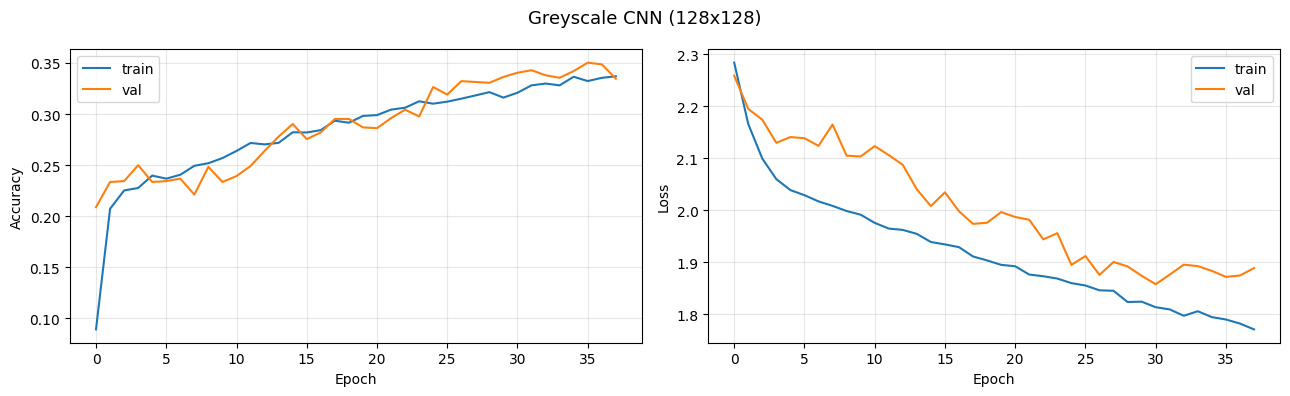

In [41]:
show_curves(hist_grey, 'Greyscale CNN (128x128)')

In [42]:
y_true_g, y_pred_g, f1_grey = report_metrics(
    grey_model, ds_val_grey, tag='Greyscale CNN (128) - Validation'
)


=== Greyscale CNN (128) - Validation ===
Accuracy :  0.3405
Macro F1 :  0.2946
Parameters: 32,906

              precision    recall  f1-score   support

     battery       0.32      0.75      0.45        67
  biological       0.38      0.32      0.34        76
   cardboard       0.40      0.35      0.37       139
     clothes       0.42      0.74      0.54       204
       glass       0.43      0.12      0.19       170
       metal       0.18      0.34      0.23        87
       paper       0.36      0.45      0.40       130
     plastic       0.35      0.10      0.15       171
       shoes       0.14      0.02      0.04       129
       trash       0.19      0.30      0.23        43

    accuracy                           0.34      1216
   macro avg       0.32      0.35      0.29      1216
weighted avg       0.34      0.34      0.30      1216



### 8.1 RGB vs Greyscale

Directly comparing the RGB and greyscale models that used the same hyperparameters.

In [43]:
print(f'{"":<16} {"Macro F1":>10} {"Params":>12}')
print('-' * 40)
print(f'{"RGB (v2)":<16} {f1_v2:>10.4f} {rgb_v2.count_params():>12,}')
print(f'{"Greyscale":<16} {f1_grey:>10.4f} {grey_model.count_params():>12,}')
print()
diff = f1_v2 - f1_grey
if diff > 0:
    print(f'RGB outperforms greyscale by {diff:.4f} macro F1.')
else:
    print(f'Greyscale outperforms RGB by {-diff:.4f} macro F1.')

                   Macro F1       Params
----------------------------------------
RGB (v2)             0.3235       33,194
Greyscale            0.2946       32,906

RGB outperforms greyscale by 0.0288 macro F1.


---

**Phase 2 complete.** All CNN-from-scratch experiments are done. The next step is transfer learning with VGG16.